In [409]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import copy

%matplotlib inline
plt.style.use('seaborn')

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV,KFold,cross_val_score
from sklearn.preprocessing import MinMaxScaler,StandardScaler,RobustScaler,LabelEncoder,OneHotEncoder
from sklearn.metrics import mean_squared_error

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# 1. Load Data

In [410]:
url = 'C:\\Users\\Lee\\Desktop\\GIt\\AIFFEL_first\\EXPLORATION\\EXPLORATION_3'

In [411]:
train = pd.read_csv(url+'/train.csv')
test  = pd.read_csv(url+'/test.csv')

In [412]:
sub_id = test.id

In [413]:
train.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


# 2. EDA

- ID : 집을 구분하는 번호
- date : 집을 구매한 날짜
- price : 집의 가격(Target variable)
- bedrooms : 침실의 수
- bathrooms : 화장실의 수
- sqft_living : 주거 공간의 평방 피트(면적)
- sqft_lot : 부지의 평방 피트(면적)
- floors : 집의 층 수
- waterfront : 집의 전방에 강이 흐르는지 유무 (a.k.a. 리버뷰)
- view : 집이 얼마나 좋아 보이는지의 정도
- condition : 집의 전반적인 상태
- grade : King County grading 시스템 기준으로 매긴 집의 등급
- sqft_above : 지하실을 제외한 평방 피트(면적)
- sqft_basement : 지하실의 평방 피트(면적)
- yr_built : 지어진 년도
- yr_renovated : 집을 재건축한 년도
- zipcode : 우편번호
- lat : 위도
- long : 경도
- sqft_living15 : 2015년 기준 주거 공간의 평방 피트(면적, 집을 재건축했다면, 변화가 있을 수 있음)
- sqft_lot15 : 2015년 기준 부지의 평방 피트(면적, 집을 재건축했다면, 변화가 있을 수 있음)

### - Data Summary

In [414]:
df = pd.concat([train,test],ignore_index=True)

In [415]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


In [416]:
print(df.shape)
df.info()

(21590, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21590 entries, 0 to 21589
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21590 non-null  int64  
 1   date           21590 non-null  object 
 2   price          15035 non-null  float64
 3   bedrooms       21590 non-null  int64  
 4   bathrooms      21590 non-null  float64
 5   sqft_living    21590 non-null  int64  
 6   sqft_lot       21590 non-null  int64  
 7   floors         21590 non-null  float64
 8   waterfront     21590 non-null  int64  
 9   view           21590 non-null  int64  
 10  condition      21590 non-null  int64  
 11  grade          21590 non-null  int64  
 12  sqft_above     21590 non-null  int64  
 13  sqft_basement  21590 non-null  int64  
 14  yr_built       21590 non-null  int64  
 15  yr_renovated   21590 non-null  int64  
 16  zipcode        21590 non-null  int64  
 17  lat            21590 non-null  float64

In [417]:
df.isnull().sum()

id                  0
date                0
price            6555
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront          0
view                0
condition           0
grade               0
sqft_above          0
sqft_basement       0
yr_built            0
yr_renovated        0
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
dtype: int64

1. id 는 idex번호 -> drop
2. date는 시간으로 datetime으로 형 변환 후 year,month 분리
3. price = target값 
4. 결측치는 안보이며 date제외 전부 수치형 데이터

In [418]:
df['date']=df['date'].str[:6].astype('int')

### -Data Statistic

In [419]:
df.describe()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21590.000000,21590.000000,1.503500e+04,21590.000000,21590.000000,21590.000000,2.159000e+04,21590.000000,21590.000000,21590.000000,...,21590.000000,21590.000000,21590.000000,21590.000000,21590.000000,21590.000000,21590.000000,21590.000000,21590.000000,21590.000000
mean,10847.025012,201438.960769,5.406827e+05,3.363826,2.108522,2077.933766,1.517736e+04,1.495322,0.007642,0.233673,...,7.654423,1789.432932,288.500834,1970.872302,83.955952,98078.466651,47.561053,-122.214326,1988.997684,12662.111811
std,6296.180260,44.399942,3.715247e+05,0.908505,0.770221,919.639296,4.226132e+04,0.538870,0.087088,0.764324,...,1.177802,832.359972,439.615528,29.458458,400.707520,53.343129,0.137931,0.140937,694.062780,27083.205927
min,0.000000,201405.000000,7.800000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,5397.250000,201407.000000,3.220000e+05,3.000000,1.500000,1420.000000,5.015000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.473300,-122.329000,1480.000000,5091.250000
50%,10794.500000,201410.000000,4.500000e+05,3.000000,2.250000,1900.000000,7.607000e+03,1.500000,0.000000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98070.000000,47.572000,-122.232000,1840.000000,7600.000000
75%,16364.750000,201502.000000,6.450000e+05,4.000000,2.500000,2560.000000,1.066825e+04,2.000000,0.000000,0.000000,...,8.000000,2220.000000,550.000000,1997.000000,0.000000,98118.000000,47.678100,-122.126000,2360.000000,10042.750000
max,21762.000000,201505.000000,7.700000e+06,10.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,...,13.000000,9410.000000,4130.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [420]:
df.corr()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,1.000000,0.004357,0.020899,-0.002343,0.049122,0.015851,-0.022206,0.098031,0.000663,-0.014769,...,0.038606,0.034227,-0.031646,0.105479,-0.015932,0.007103,0.003399,0.002887,0.010298,-0.024677
date,0.004357,1.000000,0.007717,-0.006313,-0.024088,-0.026214,0.002036,-0.020913,0.000006,0.010309,...,-0.028062,-0.022029,-0.013127,0.004004,-0.020760,-0.004206,-0.031706,0.007532,-0.019652,0.002553
price,0.020899,0.007717,1.000000,0.323672,0.525479,0.702899,0.096793,0.262588,0.265738,0.400806,...,0.667211,0.608577,0.322218,0.047290,0.140808,-0.051498,0.301604,0.023547,0.586419,0.086384
bedrooms,-0.002343,-0.006313,0.323672,1.000000,0.530324,0.598978,0.035580,0.188684,-0.005287,0.081681,...,0.375805,0.496493,0.312961,0.160171,0.026584,-0.161348,-0.010917,0.137109,0.406988,0.031210
bathrooms,0.049122,-0.024088,0.525479,0.530324,1.000000,0.755638,0.093123,0.506357,0.076025,0.185020,...,0.666226,0.688191,0.277725,0.507972,0.067220,-0.212302,0.016822,0.233576,0.571833,0.091164
sqft_living,0.015851,-0.026214,0.702899,0.598978,0.755638,1.000000,0.178716,0.359155,0.111184,0.281769,...,0.762956,0.878739,0.428130,0.320056,0.063937,-0.203423,0.052532,0.250527,0.760774,0.188473
sqft_lot,-0.022206,0.002036,0.096793,0.035580,0.093123,0.178716,1.000000,-0.001194,0.021843,0.076722,...,0.121337,0.187354,0.019127,0.058381,-0.001023,-0.127433,-0.082025,0.228912,0.144095,0.715648
floors,0.098031,-0.020913,0.262588,0.188684,0.506357,0.359155,-0.001194,1.000000,0.034320,0.035493,...,0.458110,0.525085,-0.242864,0.492745,0.014080,-0.063801,0.049472,0.131219,0.283324,-0.010527
waterfront,0.000663,0.000006,0.265738,-0.005287,0.076025,0.111184,0.021843,0.034320,1.000000,0.406003,...,0.098002,0.081249,0.078751,-0.024463,0.100351,0.030461,-0.013043,-0.037758,0.096709,0.027984
view,-0.014769,0.010309,0.400806,0.081681,0.185020,0.281769,0.076722,0.035493,0.406003,1.000000,...,0.250448,0.171284,0.265131,-0.058616,0.111116,0.089743,0.006519,-0.071895,0.280420,0.080793


In [421]:
df.corr()['price'].abs().sort_values()

date             0.007717
id               0.020899
long             0.023547
condition        0.039740
yr_built         0.047290
zipcode          0.051498
sqft_lot15       0.086384
sqft_lot         0.096793
yr_renovated     0.140808
floors           0.262588
waterfront       0.265738
lat              0.301604
sqft_basement    0.322218
bedrooms         0.323672
view             0.400806
bathrooms        0.525479
sqft_living15    0.586419
sqft_above       0.608577
grade            0.667211
sqft_living      0.702899
price            1.000000
Name: price, dtype: float64

1. 집 가격과의 상관관계는 sqft_living,grade,sqft_above,bathrooms,sqft_living15이 높다
2. 반대로 long,zipcode,yr_built,condition,sqft_lot이 상관성이 낮다.

In [422]:
df[['price','grade','condition']].corr()

,price,grade,condition
price,1.000000,0.667211,0.03974
grade,0.667211,1.000000,-0.14167
condition,0.039740,-0.141670,1.00000


In [423]:
df.waterfront.value_counts()

0    21425
1      165
Name: waterfront, dtype: int64

In [424]:
df.view.value_counts()

0    19469
2      953
3      522
1      337
4      309
Name: view, dtype: int64

### -Data Visualization

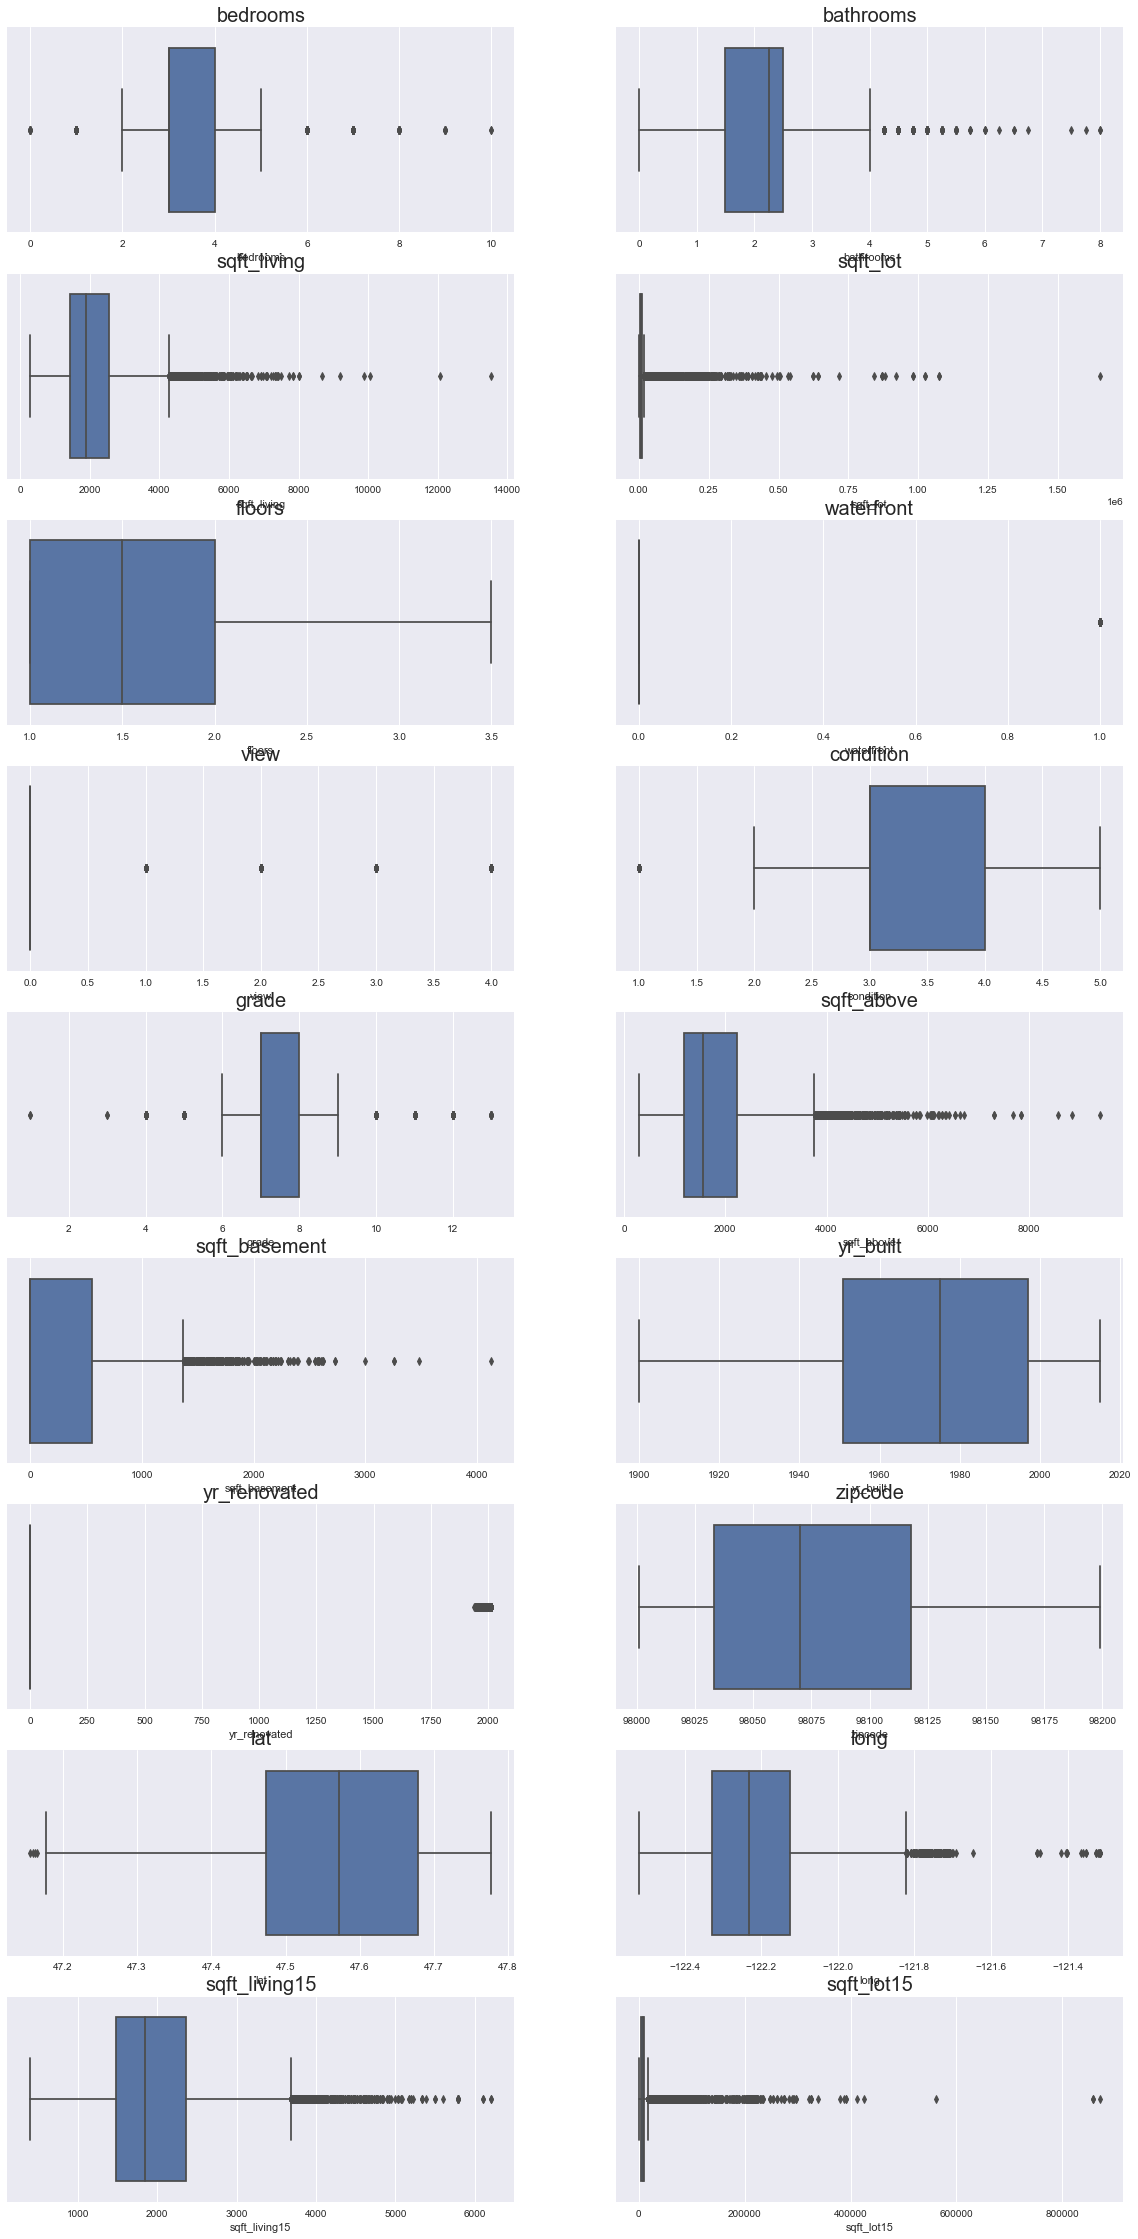

In [425]:
f , ax = plt.subplots(9,2 , figsize=(20,40))
count=3
for row in range(9):
    for col in range(2):
        sns.boxplot(df.iloc[:,count],ax=ax[row][col])
        ax[row][col].set_title(df.columns[count],fontsize =20)
        count+=1

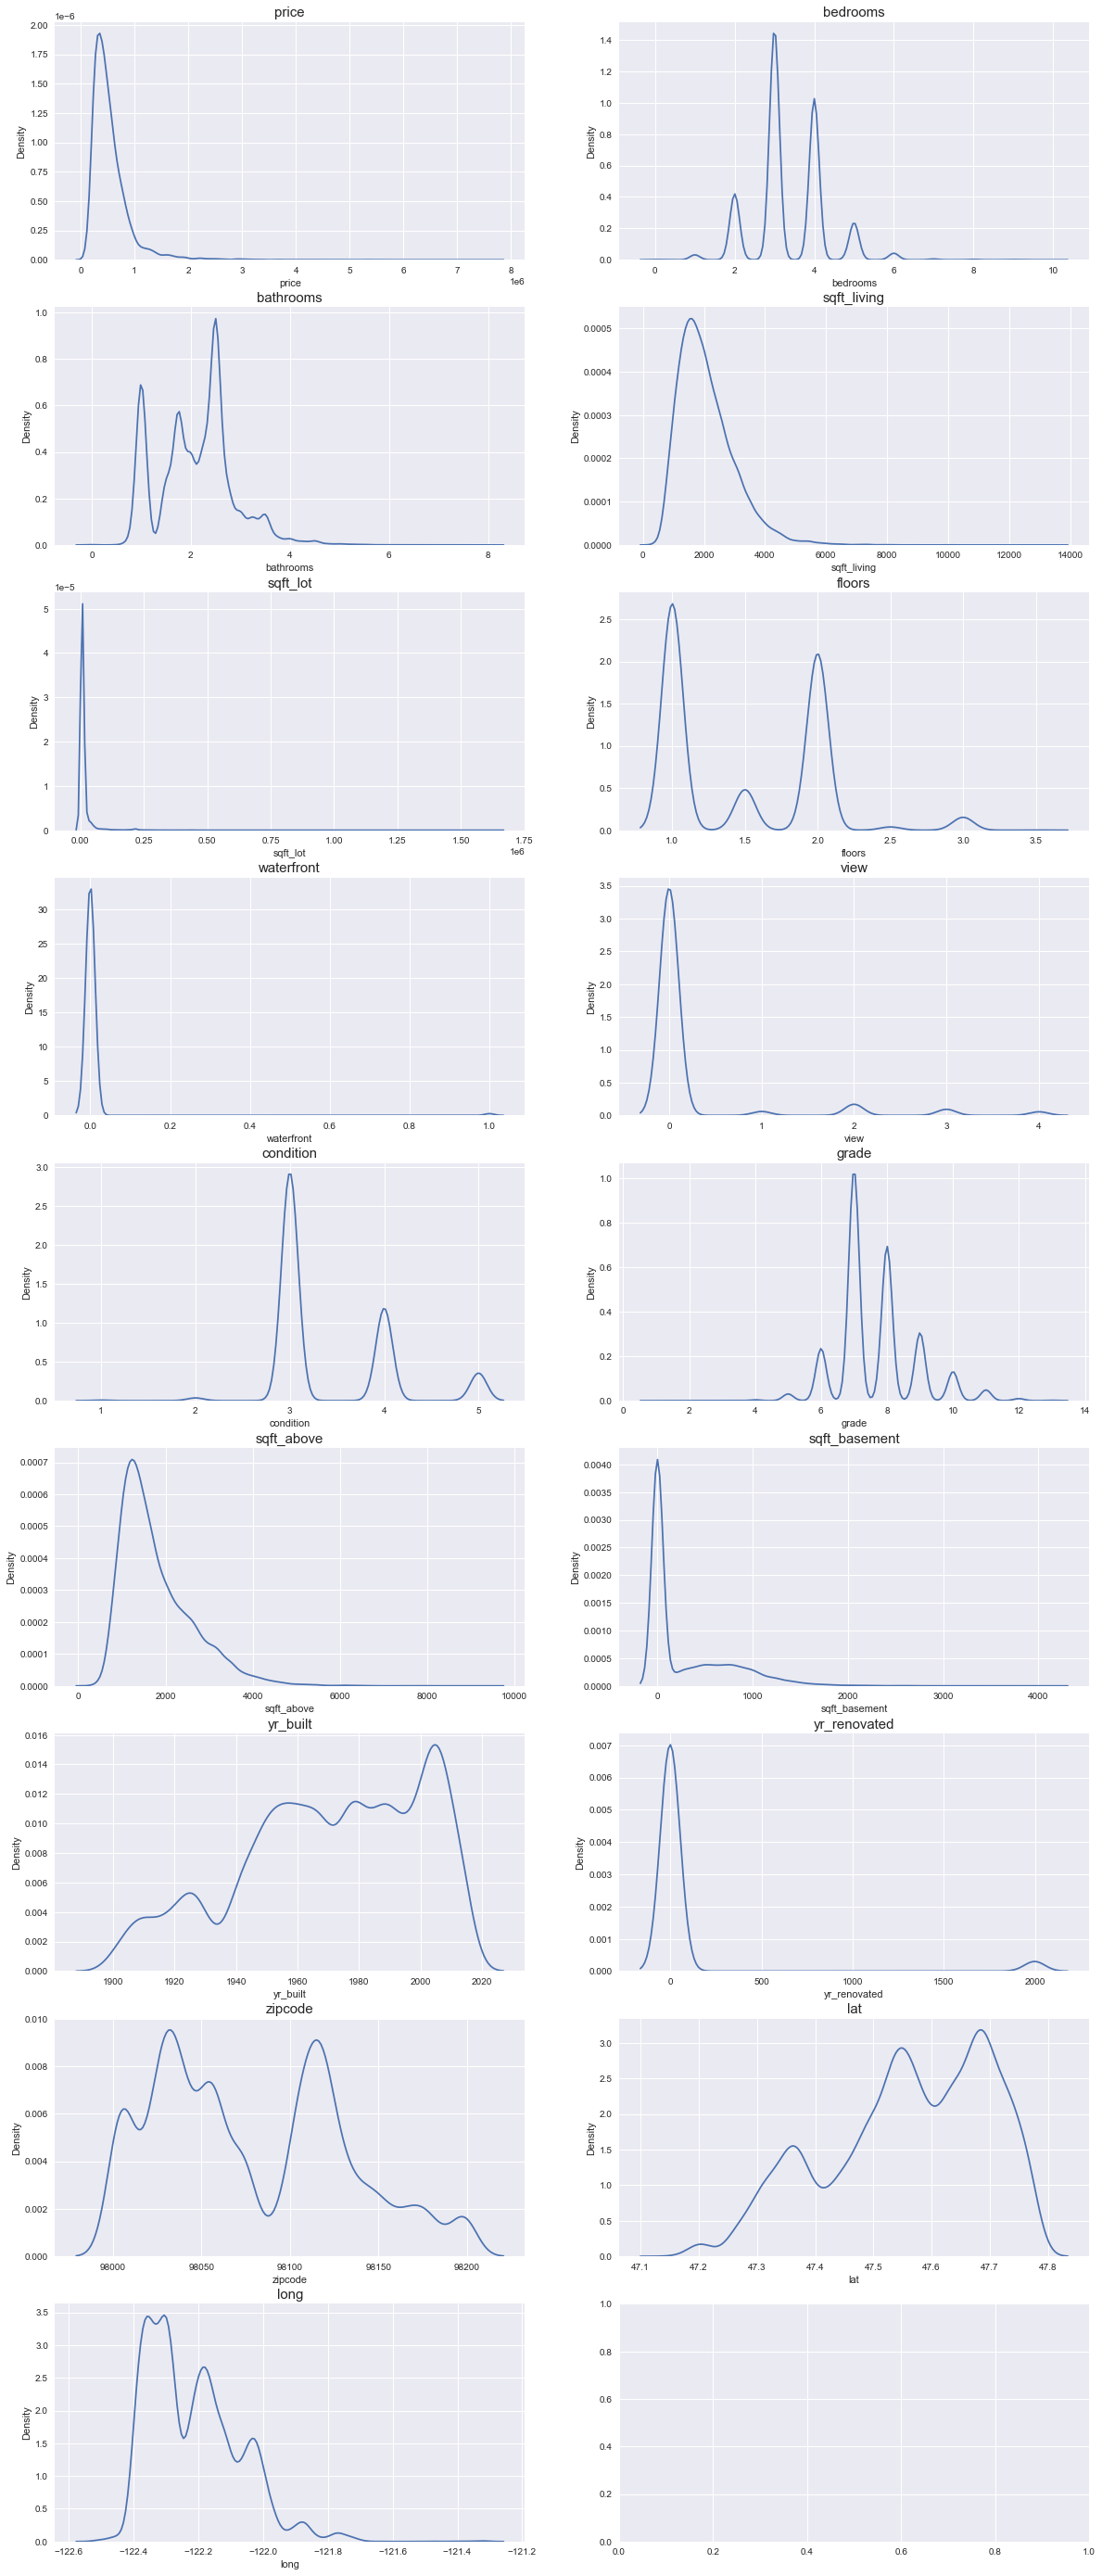

In [426]:
fig, ax = plt.subplots(9, 2, figsize=(20, 50))   # 가로스크롤 때문에 그래프 확인이 불편하다면 figsize의 x값을 조절해 보세요. 

# id 변수(count==0인 경우)는 제외하고 분포를 확인합니다.
count = 2
columns = df.columns
for row in range(9):
    for col in range(2):
        sns.kdeplot(data=df[columns[count]], ax=ax[row][col])
        ax[row][col].set_title(columns[count], fontsize=15)
        count += 1
        if count == 19 :
            break

1. price,sqft_living,sqft_lot,waterfront,view,sqft_above,sqft_basement,yr_renovated 왜도가 높다 -> scailing

# 3. FE 

# - feature 제거

In [452]:
df.drop(['id','long','lat','condition'],axis=1,inplace=True)

## - 중복치

In [456]:
df.duplicated().sum()
df=df[~df.duplicated()]

## - 정규화

In [428]:
norm = RobustScaler()
df2 = copy.deepcopy(df)
df2.iloc[:,3:]=norm.fit_transform(df2.iloc[:,3:])

In [429]:
norm = MinMaxScaler()
df3 = copy.deepcopy(df)
df3.iloc[:,3:]=norm.fit_transform(df2.iloc[:,3:])

In [430]:
df2 

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,201410,221900.0,0.0,-1.25,-0.631579,-0.346173,-0.5,0.0,0.0,...,0.0,-0.368932,0.0,-0.434783,0.0,1.270588,-0.296875,-0.123153,-0.568182,-0.393820
1,1,201502,180000.0,-1.0,-1.25,-0.991228,0.423296,-0.5,0.0,0.0,...,-1.0,-0.766990,0.0,-0.913043,0.0,-0.494118,0.810059,-0.004926,1.000000,0.093305
2,2,201502,510000.0,0.0,-0.25,-0.192982,0.083669,-0.5,0.0,0.0,...,1.0,0.116505,0.0,0.260870,0.0,0.047059,0.218750,0.921182,-0.045455,-0.019590
3,3,201406,257500.0,0.0,0.00,-0.162281,-0.139389,0.5,0.0,0.0,...,0.0,0.150485,0.0,0.434783,0.0,-0.788235,-1.280762,-0.467980,0.452273,-0.157730
4,4,201501,291850.0,0.0,-0.75,-0.736842,0.372175,-0.5,0.0,0.0,...,0.0,-0.485437,0.0,-0.260870,0.0,1.505882,-0.793457,-0.408867,-0.215909,0.426335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21585,21758,201410,NaN,1.0,0.50,0.763158,-0.664220,0.5,0.0,0.0,...,1.0,1.174757,0.0,0.847826,0.0,1.270588,-0.351074,0.000000,-0.034091,-0.395638
21586,21759,201504,NaN,0.0,0.00,-0.622807,-1.133330,1.5,0.0,0.0,...,1.0,-0.359223,0.0,0.717391,0.0,0.388235,0.401367,-0.561576,-0.750000,-1.287691
21587,21760,201410,NaN,2.0,1.50,2.254386,0.085084,0.5,0.0,0.0,...,4.0,2.825243,0.0,0.717391,0.0,-0.776471,0.293457,0.157635,1.068182,0.275472
21588,21761,201501,NaN,0.0,-0.25,-0.359649,-1.146420,1.5,0.0,0.0,...,1.0,-0.067961,0.0,0.847826,0.0,0.870588,-0.010254,-0.275862,-0.500000,-1.286479


In [431]:
df3

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,201410,221900.0,0.3,0.12500,0.067170,0.003108,0.0,0.0,0.0,...,0.500000,0.097588,0.0,0.478261,0.0,0.893939,0.571498,0.217608,0.161934,0.005742
1,1,201502,180000.0,0.2,0.12500,0.036226,0.005743,0.0,0.0,0.0,...,0.416667,0.052632,0.0,0.286957,0.0,0.136364,0.936143,0.237542,0.399415,0.008513
2,2,201502,510000.0,0.3,0.25000,0.104906,0.004579,0.0,0.0,0.0,...,0.583333,0.152412,0.0,0.756522,0.0,0.368687,0.741354,0.393688,0.241094,0.007871
3,3,201406,257500.0,0.3,0.28125,0.107547,0.003816,0.4,0.0,0.0,...,0.500000,0.156250,0.0,0.826087,0.0,0.010101,0.247386,0.159468,0.316469,0.007085
4,4,201501,291850.0,0.3,0.18750,0.058113,0.005567,0.0,0.0,0.0,...,0.500000,0.084430,0.0,0.547826,0.0,0.994949,0.407914,0.169435,0.215281,0.010407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21585,21758,201410,NaN,0.4,0.34375,0.187170,0.002018,0.4,0.0,0.0,...,0.583333,0.271930,0.0,0.991304,0.0,0.893939,0.553643,0.238372,0.242815,0.005732
21586,21759,201504,NaN,0.3,0.28125,0.067925,0.000412,0.8,0.0,0.0,...,0.583333,0.098684,0.0,0.939130,0.0,0.515152,0.801512,0.143688,0.134400,0.000658
21587,21760,201410,NaN,0.5,0.46875,0.315472,0.004584,0.4,0.0,0.0,...,0.833333,0.458333,0.0,0.939130,0.0,0.015152,0.765964,0.264950,0.409740,0.009549
21588,21761,201501,NaN,0.3,0.25000,0.090566,0.000367,0.8,0.0,0.0,...,0.583333,0.131579,0.0,0.991304,0.0,0.722222,0.665916,0.191860,0.172260,0.000665


## - Encoding
- 범주형 자료가 없다

# Model

In [432]:
xgb = XGBRegressor()
lgbm = LGBMRegressor()

In [433]:
train = df3[:15035]
test = df3[15035:]

In [434]:
y = train['price']
train.drop('price',axis=1,inplace=True)

In [435]:
x_train,x_test,y_train,y_test = train_test_split(train,y,random_state=42)

In [436]:
models = [xgb,lgbm]

In [437]:
def rmse(y_test, y_pred):
    return np.sqrt(mean_squared_error(y_test, y_pred))

In [438]:
for model in models:
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    print(rmse(y_test,y_pred))
    

141757.1956512457
130027.40899017028


In [439]:
test.drop('price',axis=1,inplace=True)

In [440]:
test

,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
15035,15208,201405,0.4,0.56250,0.387170,0.061429,0.0,0.0,0.00,0.50,0.833333,0.394737,0.370460,0.878261,0.0,0.262626,0.804568,0.426910,0.750473,0.116339
15036,15209,201503,0.3,0.31250,0.120755,0.003659,0.4,0.0,0.00,0.50,0.500000,0.175439,0.000000,0.895652,0.0,0.186869,0.341805,0.405316,0.342626,0.007948
15037,15210,201501,0.4,0.37500,0.200755,0.002714,0.4,0.0,0.75,0.50,0.666667,0.185307,0.234867,0.686957,0.0,0.631313,0.668329,0.119601,0.299604,0.003847
15038,15211,201412,0.2,0.12500,0.068679,0.005652,0.0,0.0,0.00,0.75,0.500000,0.099781,0.000000,0.182609,0.0,0.005051,0.246099,0.256645,0.113750,0.005105
15039,15212,201405,0.4,0.21875,0.100377,0.002702,0.0,0.0,0.00,0.75,0.500000,0.062500,0.184019,0.408696,0.0,0.666667,0.879202,0.147841,0.172260,0.004973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21585,21758,201410,0.4,0.34375,0.187170,0.002018,0.4,0.0,0.00,0.50,0.583333,0.271930,0.000000,0.991304,0.0,0.893939,0.553643,0.238372,0.242815,0.005732
21586,21759,201504,0.3,0.28125,0.067925,0.000412,0.8,0.0,0.00,0.50,0.583333,0.098684,0.000000,0.939130,0.0,0.515152,0.801512,0.143688,0.134400,0.000658
21587,21760,201410,0.5,0.46875,0.315472,0.004584,0.4,0.0,0.00,0.50,0.833333,0.458333,0.000000,0.939130,0.0,0.015152,0.765964,0.264950,0.409740,0.009549
21588,21761,201501,0.3,0.25000,0.090566,0.000367,0.8,0.0,0.00,0.50,0.583333,0.131579,0.000000,0.991304,0.0,0.722222,0.665916,0.191860,0.172260,0.000665


In [441]:
y_pred=model.predict(test)

In [444]:
sub = pd.DataFrame({'id':sub_id,
              'price':y_pred
             })

In [448]:
sub

,id,price
0,15208,1.276715e+06
1,15209,3.116247e+05
2,15210,7.539221e+05
3,15211,2.064950e+05
4,15212,4.642030e+05
...,...,...
6550,21758,4.290574e+05
6551,21759,5.252644e+05
6552,21760,1.759217e+06
6553,21761,3.826800e+05


In [449]:
sub.to_csv('sub.csv',index=False)